In [53]:
# Data loading
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv(r'C:\AI_Agent\AI Diagnostic Agents\Data\diagnosed_cbc_data_v4.csv')
df.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


In [6]:
df.describe()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT
count,1281.000000,1281.000000,1281.000000,1281.000000,1281.000000,1281.000000,1281.000000,1281.0000,1281.000000,1281.000000,1281.000000,1281.000000,1281.000000,1281.000000
mean,7.862717,25.845000,77.511000,1.880760,5.140940,4.708267,12.184551,46.1526,85.793919,32.084840,31.739149,229.981421,14.312512,0.260280
std,3.564466,7.038728,147.746273,1.335689,2.872294,2.817200,3.812897,104.8861,27.177663,111.170756,3.300352,93.019336,3.005079,0.685351
min,0.800000,6.200000,0.700000,0.200000,0.500000,1.360000,-10.000000,2.0000,-79.300000,10.900000,11.500000,10.000000,8.400000,0.010000
25%,6.000000,25.845000,71.100000,1.880760,5.100000,4.190000,10.800000,39.2000,81.200000,25.500000,30.600000,157.000000,13.300000,0.170000
50%,7.400000,25.845000,77.511000,1.880760,5.140940,4.600000,12.300000,46.1526,86.600000,27.800000,32.000000,213.000000,14.312512,0.260280
75%,8.680000,25.845000,77.511000,1.880760,5.140940,5.100000,13.500000,46.1526,90.200000,29.600000,32.900000,293.000000,14.700000,0.260280
max,45.700000,91.400000,5317.000000,41.800000,79.000000,90.800000,87.100000,3715.0000,990.000000,3117.000000,92.800000,660.000000,97.000000,13.600000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   object 
dtypes: float64(14), object(1)
memory usage: 150.2+ KB


In [8]:
df['LYMp'].value_counts()

LYMp
25.845    781
35.600      7
27.800      7
18.900      6
43.400      6
         ... 
47.000      1
54.500      1
13.600      1
27.600      1
25.300      1
Name: count, Length: 263, dtype: int64

In [9]:
df['NEUTp'].value_counts()

NEUTp
77.511      781
74.300        8
63.500        6
72.500        6
71.500        6
           ... 
67.000        1
79.300        1
51.400        1
5317.000      1
68.800        1
Name: count, Length: 267, dtype: int64

In [10]:
df['PDW'].value_counts()

PDW
14.312512    417
13.100000     40
13.600000     39
12.800000     36
13.300000     35
            ... 
22.500000      1
9.800000       1
22.100000      1
24.600000      1
10.800000      1
Name: count, Length: 104, dtype: int64

In [11]:
df['PCT'].value_counts()

PCT
0.26028     781
0.15000      53
0.12000      49
0.17000      45
0.13000      44
0.16000      43
0.18000      35
0.14000      33
0.11000      24
0.22000      23
0.19000      19
0.10000      17
0.20000      17
0.23000      14
0.08000      10
0.09000       9
0.24000       8
0.21000       7
0.26000       6
0.07000       6
0.25000       5
0.27000       5
0.35000       4
0.29000       3
0.28000       3
0.01000       2
0.05000       2
0.30000       2
0.03000       1
12.00000      1
0.41000       1
13.60000      1
0.04000       1
0.33000       1
0.36000       1
0.44000       1
12.80000      1
11.30000      1
0.45000       1
0.34000       1
Name: count, dtype: int64

Redundant values

In [12]:
df.drop(columns=['PCT', 'LYMp', 'NEUTp'], inplace=True)

Derive new values for LYMp, NEUTp

In [13]:
#  To check if WBC values are 0
wbc_zero_mask = df["WBC"].eq(0).sum()
print(wbc_zero_mask)

0


In [14]:
# Derived LYMp, NEUTp values
df['new_LYMp'] = (df['LYMn'] / df['WBC']) * 100
df['new_NEUTp'] = (df['NEUTn'] / df['WBC']) * 100

In [15]:
df.rename(columns={'new_LYMp': 'LYMp', 'new_NEUTp': 'NEUTp'}, inplace=True)

In [16]:
df.head()

,WBC,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,Diagnosis,LYMp,NEUTp
0,10.0,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,Normocytic hypochromic anemia,43.000000,50.000000
1,10.0,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,Normocytic hypochromic anemia,42.000000,53.000000
2,7.2,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,Iron deficiency anemia,30.555556,61.111111
3,6.0,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,Iron deficiency anemia,30.000000,63.333333
4,4.2,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,Normocytic hypochromic anemia,38.095238,54.761905


In [17]:
# Lets make a copy of this dataset
df_copy = df.copy()

 Define physiologically implausible ranges

In [18]:
hgb_invalid = (df_copy['HGB'] < 5) | (df_copy['HGB'] > 25)
rbc_invalid = (df_copy['RBC'] < 2) | (df_copy['RBC'] > 8)
mcv_invalid = (df_copy['MCV'] < 50) | (df_copy['MCV'] > 130)
hct_invalid = (df_copy['HCT'] < 15) | (df_copy['HCT'] > 60)
plt_invalid = (df_copy['PLT'] < 30) | (df_copy['PLT'] > 700)
wbc_invalid = (df_copy['WBC'] < 2) | (df_copy['WBC'] > 30)

In [19]:
print('Values in which HGB is Invalid: ',hgb_invalid.sum())
print('Values in which RBC is Invalid: ',rbc_invalid.sum())
print('Values in which MCV is Invalid: ',mcv_invalid.sum())
print('Values in which HCT is Invalid: ',hct_invalid.sum())
print('Values in which PLT is Invalid: ',plt_invalid.sum())
print('Values in which WBC is Invalid: ',wbc_invalid.sum())

Values in which HGB is Invalid:  13
Values in which RBC is Invalid:  11
Values in which MCV is Invalid:  8
Values in which HCT is Invalid:  9
Values in which PLT is Invalid:  9
Values in which WBC is Invalid:  5


In [20]:
# To find affected rows
affected_rows = hgb_invalid | rbc_invalid | mcv_invalid | hct_invalid | plt_invalid | wbc_invalid
affected_rows.sum()

np.int64(34)

In [21]:
affected_data = df_copy.loc[
    affected_rows,
    [
        "WBC", "LYMn", "NEUTn",
        "RBC", "HGB", "HCT",
        "MCV", "MCH", "MCHC",
        "PLT", "PDW",
        "Diagnosis"
    ]
]

print(affected_data)

        WBC      LYMn     NEUTn    RBC    HGB        HCT     MCV     MCH  \
3      6.00   1.80000   3.80000   4.22   3.80    32.8000   77.90    23.2   
4      4.20   1.60000   2.30000   3.93   0.40   316.0000   80.60    23.9   
76    11.80   1.30000   9.40000   4.58   1.20    35.1000   76.80    24.4   
113    2.50   0.90000   1.40000   3.55   8.60    28.5000   80.30    24.2   
140    0.80   1.70000   1.90000   3.99   7.30    28.1000   70.50    18.2   
201   10.50   1.30000   8.30000   4.57  12.40    38.9000   85.30    27.1   
206    6.00   2.00000   0.50000   3.20   4.82    12.1000   36.60    76.0   
241    6.50   3.00000  12.90000  41.10  85.10    26.6000   31.30    37.2   
245    9.10   0.80000   7.80000   4.66 -10.00    34.6000   74.40    21.4   
271   10.90   1.20000   3.40000   4.89  14.50    14.0000   91.20    90.0   
273    7.10   1.20000   3.00000  90.80  12.60    39.4000   83.30    26.5   
292   21.10   4.90000  14.20000   1.42   3.10    10.1000   71.80    21.8   
344    3.20 

In [22]:
# Rewriting invalid values as nan
df_copy.loc[hgb_invalid, 'HGB'] = np.nan
df_copy.loc[rbc_invalid, 'RBC'] = np.nan
df_copy.loc[mcv_invalid, 'MCV'] = np.nan
df_copy.loc[hct_invalid, 'HCT'] = np.nan
df_copy.loc[plt_invalid, 'PLT'] = np.nan
df_copy.loc[wbc_invalid, 'WBC'] = np.nan

In [23]:
# Cross verify to check if values are nan
print("HGB converted to NaN:", hgb_invalid.sum())
print("RBC converted to NaN:", rbc_invalid.sum())
print("MCV converted to NaN:", mcv_invalid.sum())
print("HCT converted to NaN:", hct_invalid.sum())
print("PLT converted to NaN:", plt_invalid.sum())
print("WBC converted to NaN:", wbc_invalid.sum())

print(df_copy[['HGB', 'RBC', 'MCV', 'HCT', 'PLT', 'WBC']].isnull().sum())

HGB converted to NaN: 13
RBC converted to NaN: 11
MCV converted to NaN: 8
HCT converted to NaN: 9
PLT converted to NaN: 9
WBC converted to NaN: 5
HGB    13
RBC    11
MCV     8
HCT     9
PLT     9
WBC     5
dtype: int64


In [24]:
duplicate_count = df_copy.duplicated().sum()
print(duplicate_count)

54


In [25]:
df_copy = df_copy.drop_duplicates().copy()
print(f"Rows after removing duplicates: {len(df_copy)}")
print(f"Duplicates remaining: {df_copy.duplicated().sum()}")

Rows after removing duplicates: 1227
Duplicates remaining: 0


In [26]:
# Check class distribution
class_counts = df_copy["Diagnosis"].value_counts()

print(class_counts)

Diagnosis
Healthy                           323
Normocytic hypochromic anemia     266
Normocytic normochromic anemia    255
Iron deficiency anemia            184
Thrombocytopenia                   72
Other microcytic anemia            56
Leukemia                           44
Macrocytic anemia                  16
Leukemia with thrombocytopenia     11
Name: count, dtype: int64


In [27]:
class_percentages = df_copy["Diagnosis"].value_counts(normalize=True) * 100

print(class_percentages.round(2))

Diagnosis
Healthy                           26.32
Normocytic hypochromic anemia     21.68
Normocytic normochromic anemia    20.78
Iron deficiency anemia            15.00
Thrombocytopenia                   5.87
Other microcytic anemia            4.56
Leukemia                           3.59
Macrocytic anemia                  1.30
Leukemia with thrombocytopenia     0.90
Name: proportion, dtype: float64


In [28]:
# Diagnosis Distribution
class_distribution = pd.DataFrame({
    "Count": df_copy['Diagnosis'].value_counts(),
    "Percentage": (df_copy['Diagnosis'].value_counts(normalize=True) * 100).round(2)
})

print(class_distribution)

                                Count  Percentage
Diagnosis                                        
Healthy                           323       26.32
Normocytic hypochromic anemia     266       21.68
Normocytic normochromic anemia    255       20.78
Iron deficiency anemia            184       15.00
Thrombocytopenia                   72        5.87
Other microcytic anemia            56        4.56
Leukemia                           44        3.59
Macrocytic anemia                  16        1.30
Leukemia with thrombocytopenia     11        0.90


In [29]:
df_copy

,WBC,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,Diagnosis,LYMp,NEUTp
0,10.00,4.30000,5.00000,2.77,7.3,24.2000,87.7,26.3,30.1,189.0,12.500000,Normocytic hypochromic anemia,43.000000,50.000000
1,10.00,4.20000,5.30000,2.84,7.3,25.0000,88.2,25.7,20.2,180.0,12.500000,Normocytic hypochromic anemia,42.000000,53.000000
2,7.20,2.20000,4.40000,3.97,9.0,30.5000,77.0,22.6,29.5,148.0,14.300000,Iron deficiency anemia,30.555556,61.111111
3,6.00,1.80000,3.80000,4.22,NaN,32.8000,77.9,23.2,29.8,143.0,11.300000,Iron deficiency anemia,30.000000,63.333333
4,4.20,1.60000,2.30000,3.93,NaN,NaN,80.6,23.9,29.7,236.0,12.800000,Normocytic hypochromic anemia,38.095238,54.761905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1276,4.40,1.88076,5.14094,4.86,13.5,46.1526,80.7,27.7,34.4,180.0,14.312512,Healthy,42.744545,116.839545
1277,5.60,1.88076,5.14094,4.85,15.0,46.1526,91.7,31.0,33.8,215.0,14.312512,Healthy,33.585000,91.802500
1278,9.20,1.88076,5.14094,4.47,13.1,46.1526,88.7,29.3,33.0,329.0,14.312512,Healthy,20.443043,55.879783
1279,6.48,1.88076,5.14094,4.75,13.2,46.1526,86.7,27.9,32.1,174.0,14.312512,Healthy,29.024074,79.335494


Feature Sanity Check for HCT :                                 
---
HCT ≈ (RBC×MCV)​ / 10

In [30]:
df_copy['HCT_expected'] = (df_copy['RBC'] * df_copy['MCV']) / 10

In [31]:
# Comparing expected with original
df_copy['HCT_diff'] = (df_copy['HCT'] - df_copy['HCT_expected']).abs()

In [32]:
print(
    df_copy[
        ["RBC", "MCV", "HCT", "HCT_expected", "HCT_diff"]
    ].head(10)
)

    RBC   MCV   HCT  HCT_expected  HCT_diff
0  2.77  87.7  24.2       24.2929    0.0929
1  2.84  88.2  25.0       25.0488    0.0488
2  3.97  77.0  30.5       30.5690    0.0690
3  4.22  77.9  32.8       32.8738    0.0738
4  3.93  80.6   NaN       31.6758       NaN
5  3.96  75.2  29.7       29.7792    0.0792
6  5.15  87.1  44.8       44.8565    0.0565
7  4.39  86.4  37.9       37.9296    0.0296
8  4.85  84.7  41.0       41.0795    0.0795
9  4.57  85.3  38.9       38.9821    0.0821


In [33]:
# Calculate relative error
df_copy['HCT_rel_error'] = (df_copy['HCT_diff'] / df_copy['HCT'])
df_copy['HCT_rel_error_percentage'] = df_copy['HCT_rel_error'] * 100

In [34]:
# Finding Inconsistency
hct_inconsistent = (df_copy['HCT_rel_error'] > 0.10)

print("Rows havig inconsistent HCT i.e. Relative Error HCT > 0.1 : ", hct_inconsistent.sum())

Rows havig inconsistent HCT i.e. Relative Error HCT > 0.1 :  522


In [35]:
# After you clean HGB, MCV, RBC negatives in Step 3:
df_copy["HCT_calculated"] = (df_copy["RBC"] * df_copy["MCV"]) / 10
df_copy["HCT_rel_error"] = abs(
    df_copy["HCT"] - df_copy["HCT_calculated"]
) / df_copy["HCT_calculated"]

# Check different thresholds
for threshold in [0.05, 0.10, 0.15, 0.20]:
    flagged = (df_copy["HCT_rel_error"] > threshold).sum()
    print(f"Threshold {threshold*100:.0f}%: {flagged} rows flagged")

Threshold 5%: 623 rows flagged
Threshold 10%: 516 rows flagged
Threshold 15%: 377 rows flagged
Threshold 20%: 304 rows flagged


### HCT 50% data is calculated, still going to keep it


In [36]:
# Calculate actual / calculated ratio
df_copy["HCT_ratio"] = (
    df_copy["HCT"] / df_copy["HCT_calculated"]
)

print(df_copy["HCT_ratio"].describe())

count    1208.000000
mean        1.111986
std         0.217453
min         0.572005
25%         0.997964
50%         0.999808
75%         1.199841
max         2.767142
Name: HCT_ratio, dtype: float64


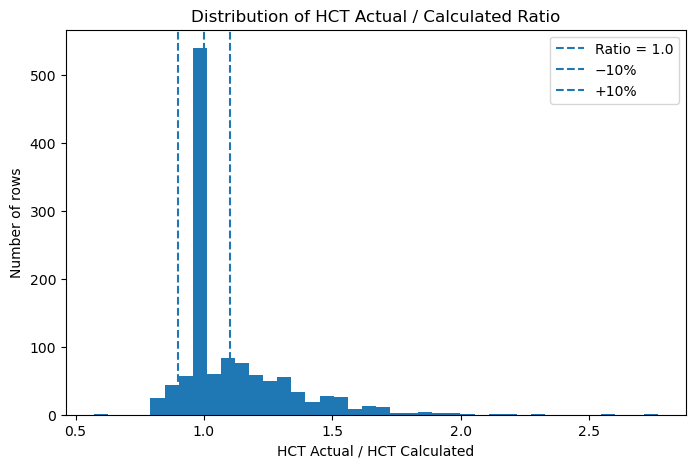

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_copy["HCT_ratio"].dropna(),
    bins=40
)

plt.axvline(1.0, linestyle="--", label="Ratio = 1.0")
plt.axvline(0.9, linestyle="--", label="−10%")
plt.axvline(1.1, linestyle="--", label="+10%")

plt.xlabel("HCT Actual / HCT Calculated")
plt.ylabel("Number of rows")
plt.title("Distribution of HCT Actual / Calculated Ratio")
plt.legend()

plt.show()

In [38]:
hct_rat = df_copy["HCT"] / (df_copy["RBC"] * df_copy["MCV"] / 10)
calculated_hct_rows = (hct_rat > 0.99) & (hct_rat < 1.01)

print(f"Rows with calculated HCT (ratio ~1.0): {calculated_hct_rows.sum()}")
print(f"Rows with independently measured HCT: {(~calculated_hct_rows).sum()}")

# Mark them for reference
df_copy["HCT_source"] = np.where(calculated_hct_rows, "calculated", "measured")

Rows with calculated HCT (ratio ~1.0): 476
Rows with independently measured HCT: 751


Drop HCT Helper cloumns

In [39]:
df_copy

,WBC,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,...,Diagnosis,LYMp,NEUTp,HCT_expected,HCT_diff,HCT_rel_error,HCT_rel_error_percentage,HCT_calculated,HCT_ratio,HCT_source
0,10.00,4.30000,5.00000,2.77,7.3,24.2000,87.7,26.3,30.1,189.0,...,Normocytic hypochromic anemia,43.000000,50.000000,24.2929,0.0929,0.003824,0.383884,24.2929,0.996176,calculated
1,10.00,4.20000,5.30000,2.84,7.3,25.0000,88.2,25.7,20.2,180.0,...,Normocytic hypochromic anemia,42.000000,53.000000,25.0488,0.0488,0.001948,0.195200,25.0488,0.998052,calculated
2,7.20,2.20000,4.40000,3.97,9.0,30.5000,77.0,22.6,29.5,148.0,...,Iron deficiency anemia,30.555556,61.111111,30.5690,0.0690,0.002257,0.226230,30.5690,0.997743,calculated
3,6.00,1.80000,3.80000,4.22,NaN,32.8000,77.9,23.2,29.8,143.0,...,Iron deficiency anemia,30.000000,63.333333,32.8738,0.0738,0.002245,0.225000,32.8738,0.997755,calculated
4,4.20,1.60000,2.30000,3.93,NaN,NaN,80.6,23.9,29.7,236.0,...,Normocytic hypochromic anemia,38.095238,54.761905,31.6758,NaN,NaN,NaN,31.6758,NaN,measured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1276,4.40,1.88076,5.14094,4.86,13.5,46.1526,80.7,27.7,34.4,180.0,...,Healthy,42.744545,116.839545,39.2202,6.9324,0.176756,15.020606,39.2202,1.176756,measured
1277,5.60,1.88076,5.14094,4.85,15.0,46.1526,91.7,31.0,33.8,215.0,...,Healthy,33.585000,91.802500,44.4745,1.6781,0.037732,3.635982,44.4745,1.037732,measured
1278,9.20,1.88076,5.14094,4.47,13.1,46.1526,88.7,29.3,33.0,329.0,...,Healthy,20.443043,55.879783,39.6489,6.5037,0.164032,14.091730,39.6489,1.164032,measured
1279,6.48,1.88076,5.14094,4.75,13.2,46.1526,86.7,27.9,32.1,174.0,...,Healthy,29.024074,79.335494,41.1825,4.9701,0.120685,10.768841,41.1825,1.120685,measured


In [40]:
hct_helper_columns = [
    "HCT_calculated",
    "HCT_diff",
    "HCT_rel_error",
    "HCT_rel_error_percentage",
    "HCT_ratio",
    "HCT_source",
    "HCT_expected"
]

df_copy.drop(
    columns=hct_helper_columns,
    inplace=True,
    errors="ignore"
)

In [41]:
df_copy

,WBC,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,Diagnosis,LYMp,NEUTp
0,10.00,4.30000,5.00000,2.77,7.3,24.2000,87.7,26.3,30.1,189.0,12.500000,Normocytic hypochromic anemia,43.000000,50.000000
1,10.00,4.20000,5.30000,2.84,7.3,25.0000,88.2,25.7,20.2,180.0,12.500000,Normocytic hypochromic anemia,42.000000,53.000000
2,7.20,2.20000,4.40000,3.97,9.0,30.5000,77.0,22.6,29.5,148.0,14.300000,Iron deficiency anemia,30.555556,61.111111
3,6.00,1.80000,3.80000,4.22,NaN,32.8000,77.9,23.2,29.8,143.0,11.300000,Iron deficiency anemia,30.000000,63.333333
4,4.20,1.60000,2.30000,3.93,NaN,NaN,80.6,23.9,29.7,236.0,12.800000,Normocytic hypochromic anemia,38.095238,54.761905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1276,4.40,1.88076,5.14094,4.86,13.5,46.1526,80.7,27.7,34.4,180.0,14.312512,Healthy,42.744545,116.839545
1277,5.60,1.88076,5.14094,4.85,15.0,46.1526,91.7,31.0,33.8,215.0,14.312512,Healthy,33.585000,91.802500
1278,9.20,1.88076,5.14094,4.47,13.1,46.1526,88.7,29.3,33.0,329.0,14.312512,Healthy,20.443043,55.879783
1279,6.48,1.88076,5.14094,4.75,13.2,46.1526,86.7,27.9,32.1,174.0,14.312512,Healthy,29.024074,79.335494


### **Report to check Nan Rows affecting minority **

In [42]:
# See which classes have NaNs
nan_mask = df_copy[['HGB', 'RBC', 'MCV', 'HCT', 'PLT', 'WBC']].isnull().any(axis=1)
nan_by_class = df_copy[nan_mask]['Diagnosis'].value_counts()
print("NaN distribution by diagnosis:")
print(nan_by_class)

# Also check: what % of each class is affected?
for diagnosis in df_copy['Diagnosis'].unique():
    total_in_class = (df_copy['Diagnosis'] == diagnosis).sum()
    nan_in_class = ((df_copy['Diagnosis'] == diagnosis) & nan_mask).sum()
    pct = (nan_in_class / total_in_class) * 100
    print(f"{diagnosis}: {nan_in_class}/{total_in_class} ({pct:.1f}%)")

NaN distribution by diagnosis:
Diagnosis
Iron deficiency anemia            9
Normocytic hypochromic anemia     9
Other microcytic anemia           6
Normocytic normochromic anemia    3
Thrombocytopenia                  3
Macrocytic anemia                 2
Leukemia                          1
Name: count, dtype: int64
Normocytic hypochromic anemia: 9/266 (3.4%)
Iron deficiency anemia: 9/184 (4.9%)
Other microcytic anemia: 6/56 (10.7%)
Leukemia: 1/44 (2.3%)
Healthy: 0/323 (0.0%)
Thrombocytopenia: 3/72 (4.2%)
Normocytic normochromic anemia: 3/255 (1.2%)
Leukemia with thrombocytopenia: 0/11 (0.0%)
Macrocytic anemia: 2/16 (12.5%)


In [43]:
# Dropping 34 rows containing NaN vaues
# Drop rows with any NaN in core CBC parameters
nan_mask = df_copy[['HGB', 'RBC', 'MCV', 'HCT', 'PLT', 'WBC']].isnull().any(axis=1)
print(f"Rows before Removing NaN : {len(df_copy)}")


Rows before Removing NaN : 1227


In [44]:
df_clean = df_copy[~nan_mask].copy()

print(f"Rows after removing NaNs: {len(df_clean)}")
print(f"Rows removed: {nan_mask.sum()}")

Rows after removing NaNs: 1194
Rows removed: 33


In [45]:
# Verify class distribution after removal
print("\nClass distribution after cleaning:")
print(df_clean['Diagnosis'].value_counts())


Class distribution after cleaning:
Diagnosis
Healthy                           323
Normocytic hypochromic anemia     257
Normocytic normochromic anemia    252
Iron deficiency anemia            175
Thrombocytopenia                   69
Other microcytic anemia            50
Leukemia                           43
Macrocytic anemia                  14
Leukemia with thrombocytopenia     11
Name: count, dtype: int64


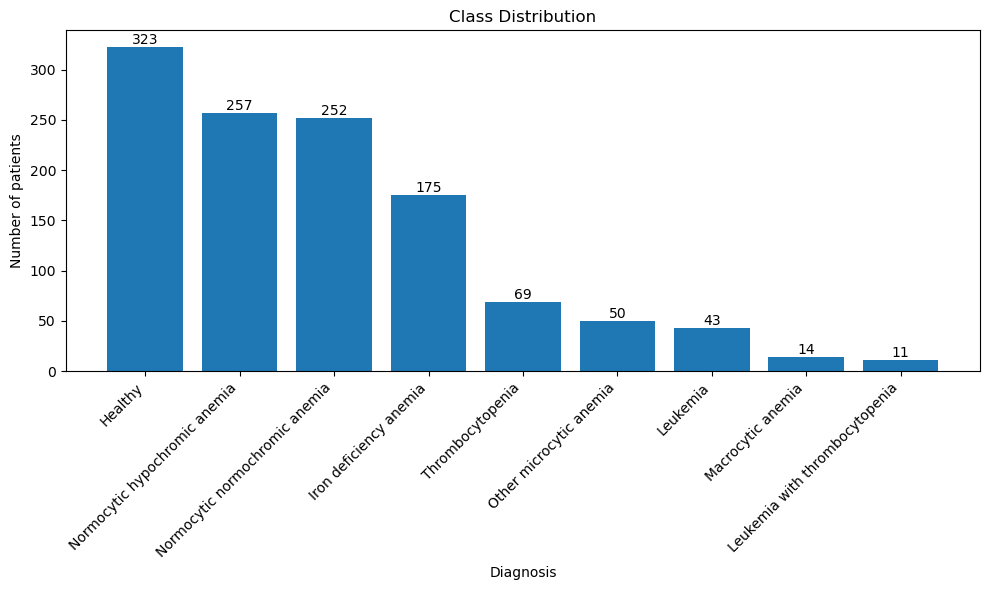

In [46]:
# Class counts
class_counts = df_clean["Diagnosis"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of patients")
plt.title("Class Distribution")

plt.xticks(rotation=45, ha="right")

# Add counts above bars
for i, value in enumerate(class_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [47]:
# numeric Feature required for visualization
numeric_features = [
    "WBC",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC",
    "PLT",
    "PDW",
    "LYMn",
    "LYMp",
    "NEUTn",
    "NEUTp"
]


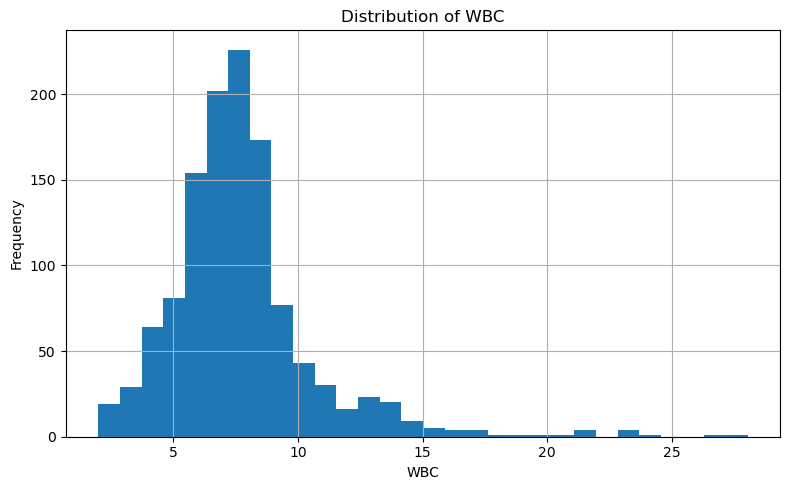

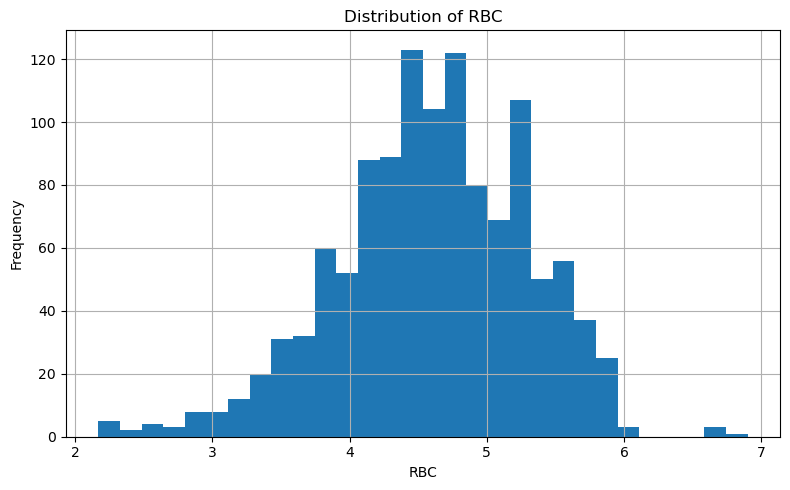

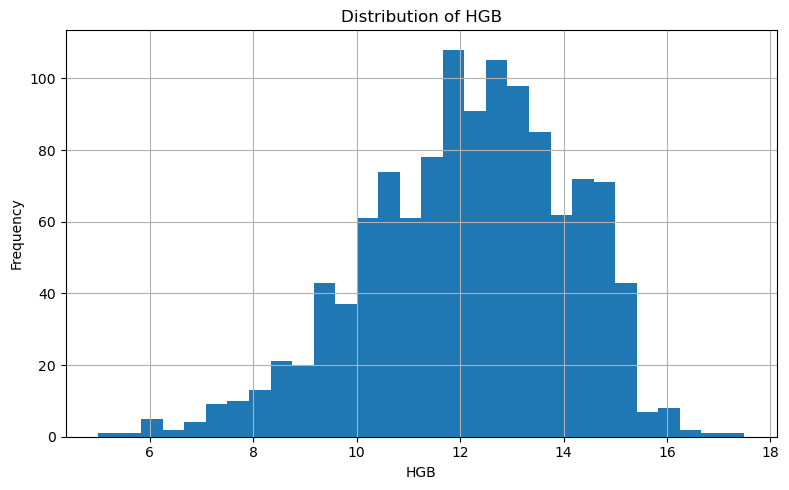

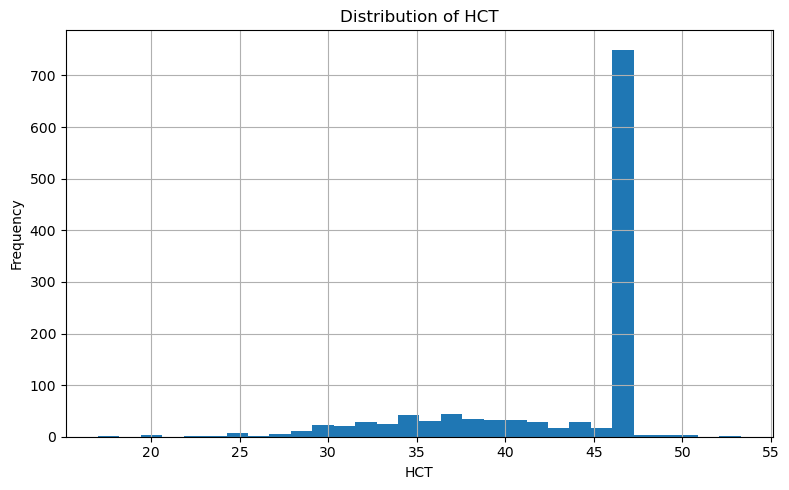

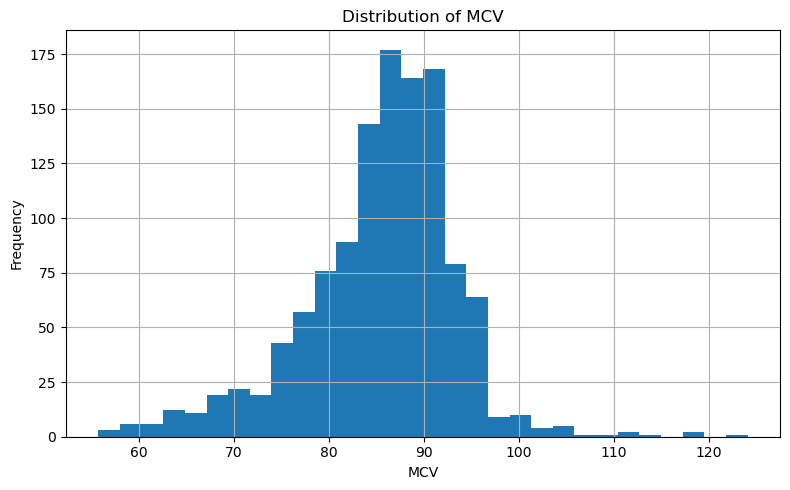

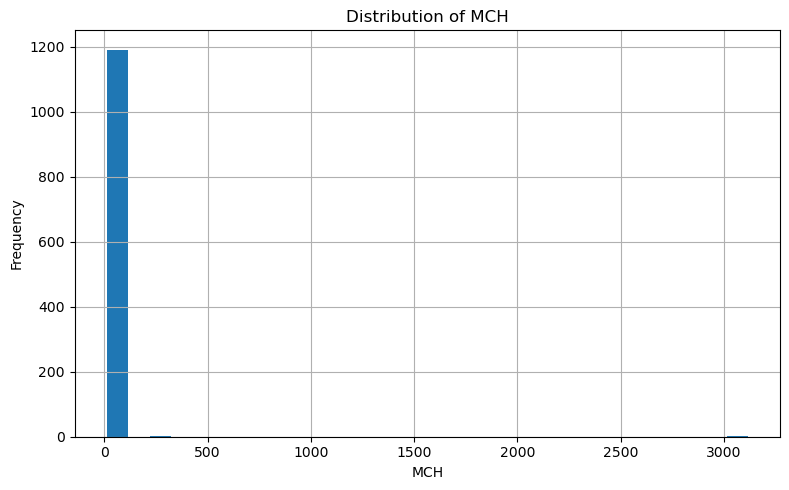

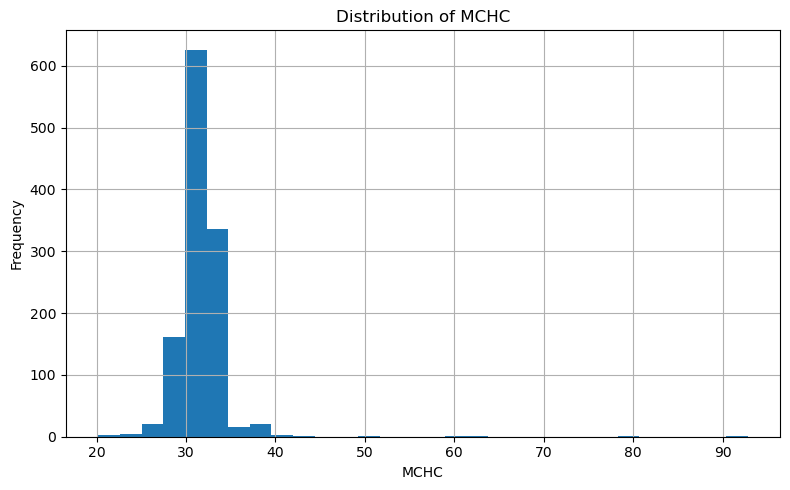

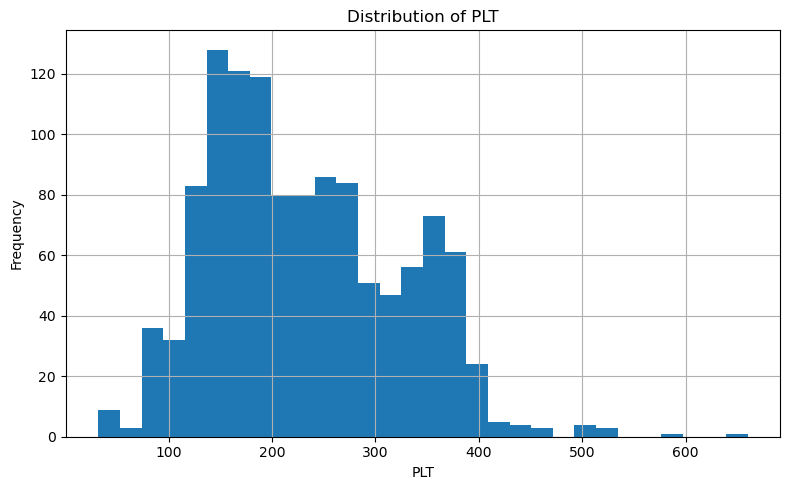

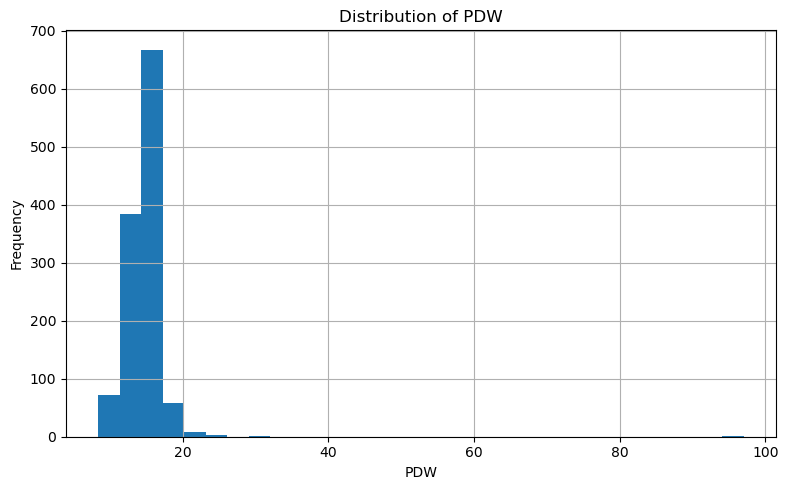

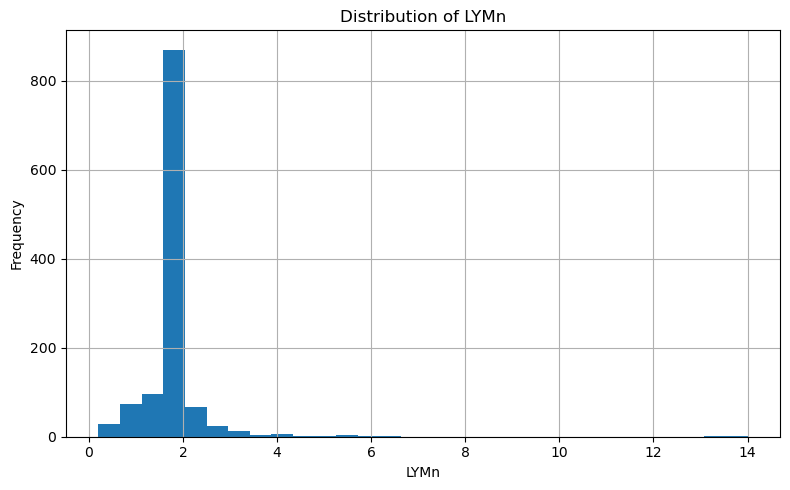

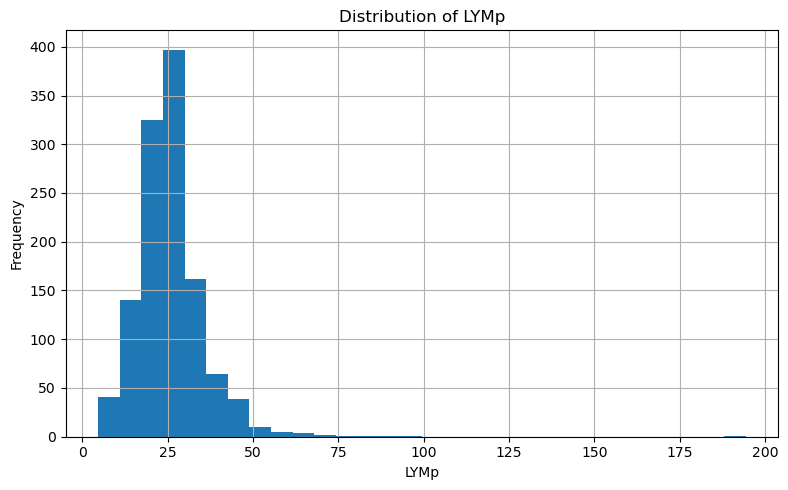

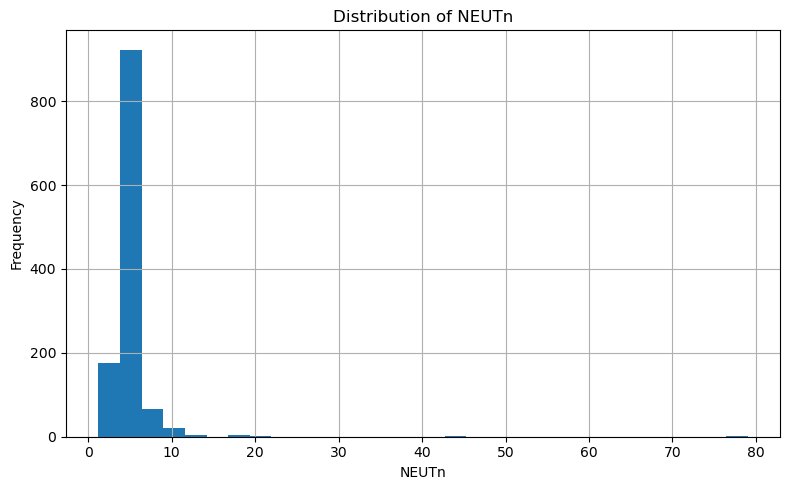

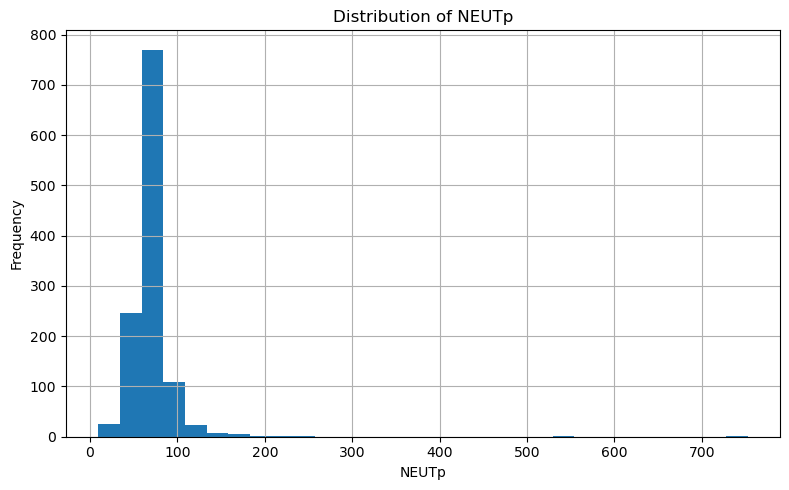

In [48]:
for col in numeric_features:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df_clean[col].dropna(),
        bins=30
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

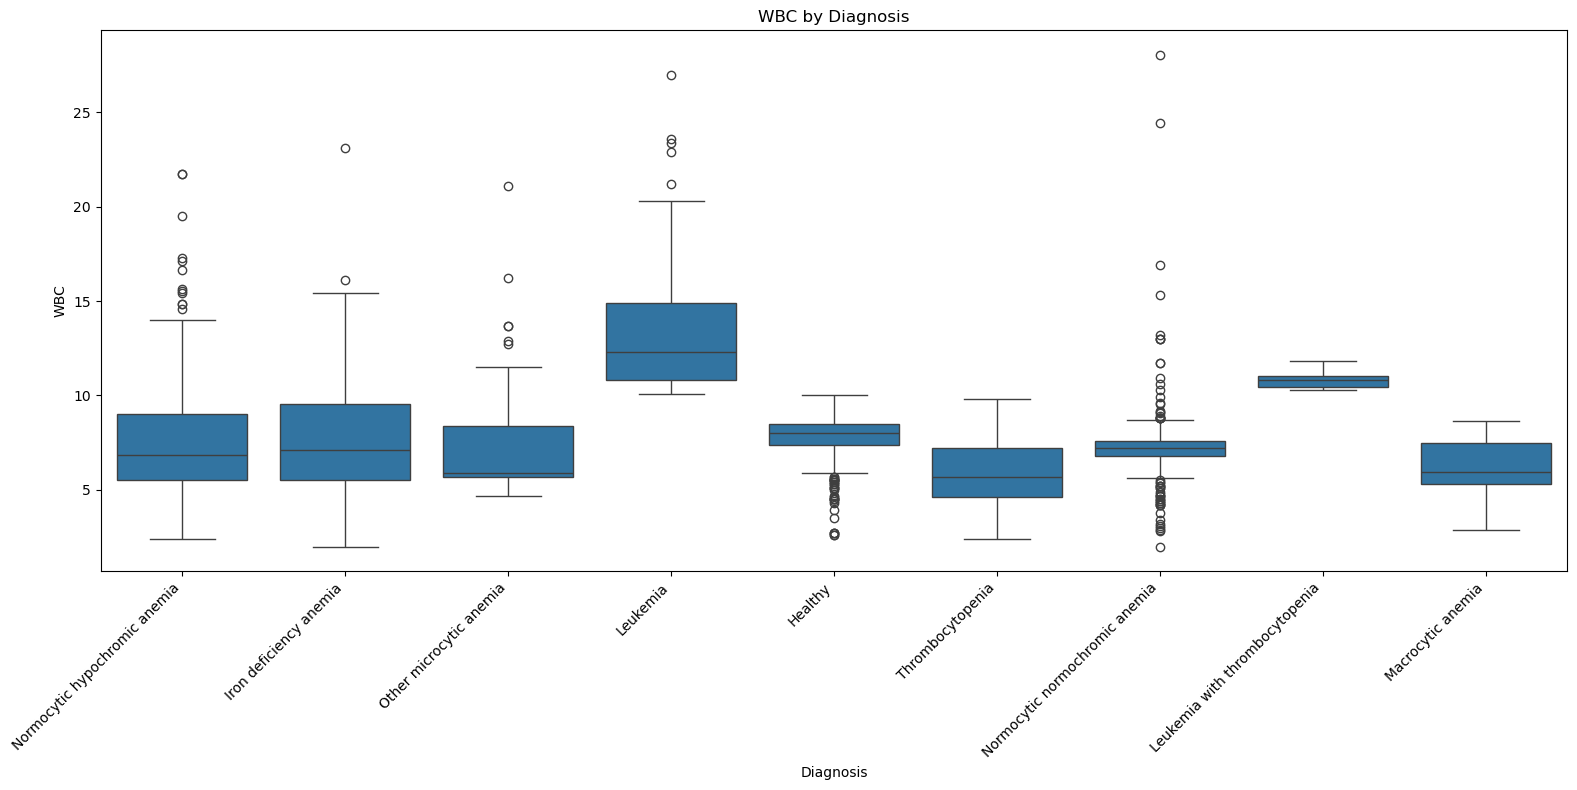

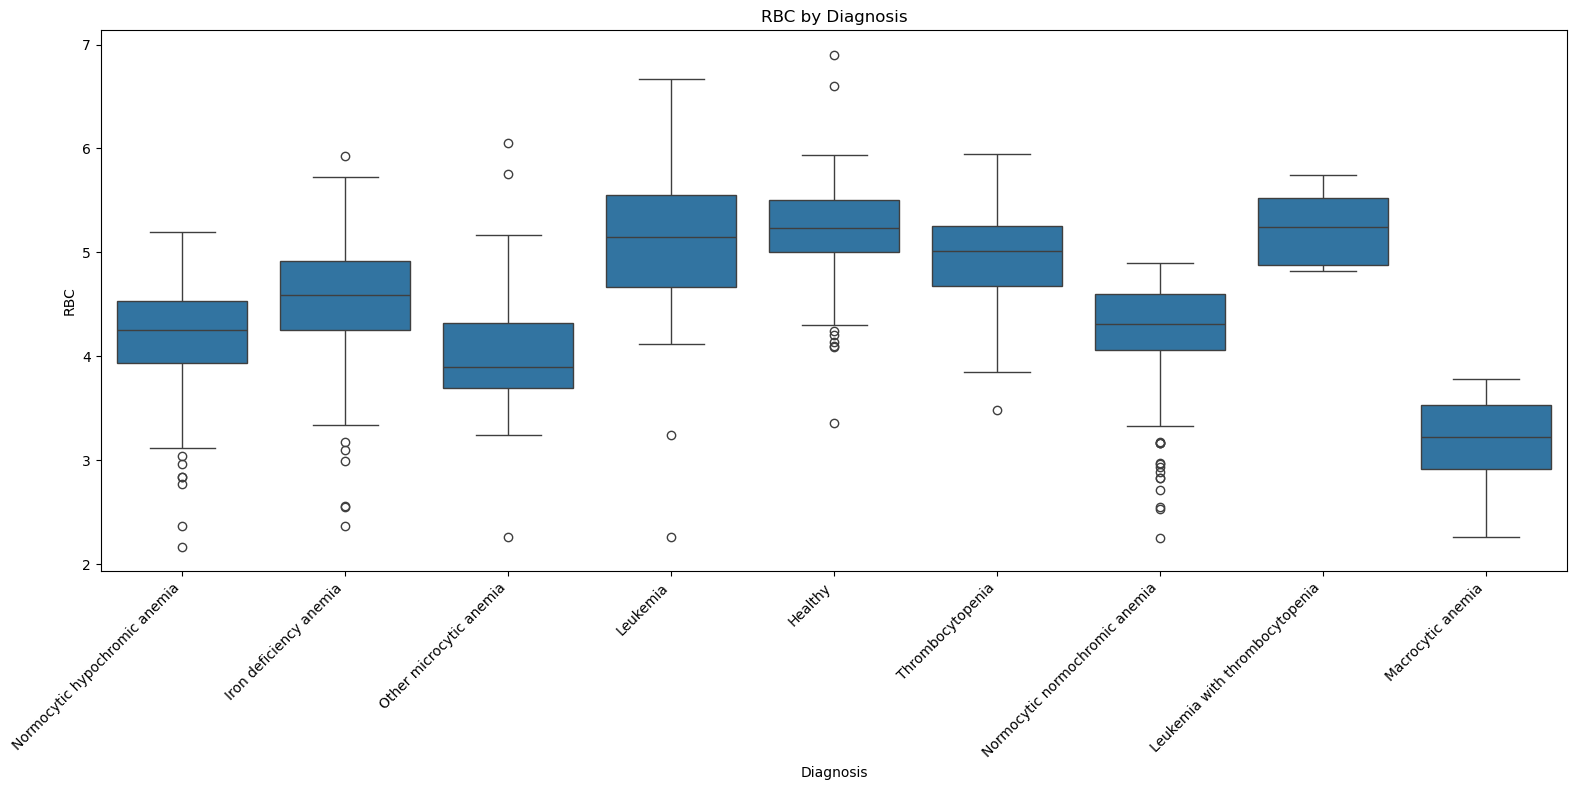

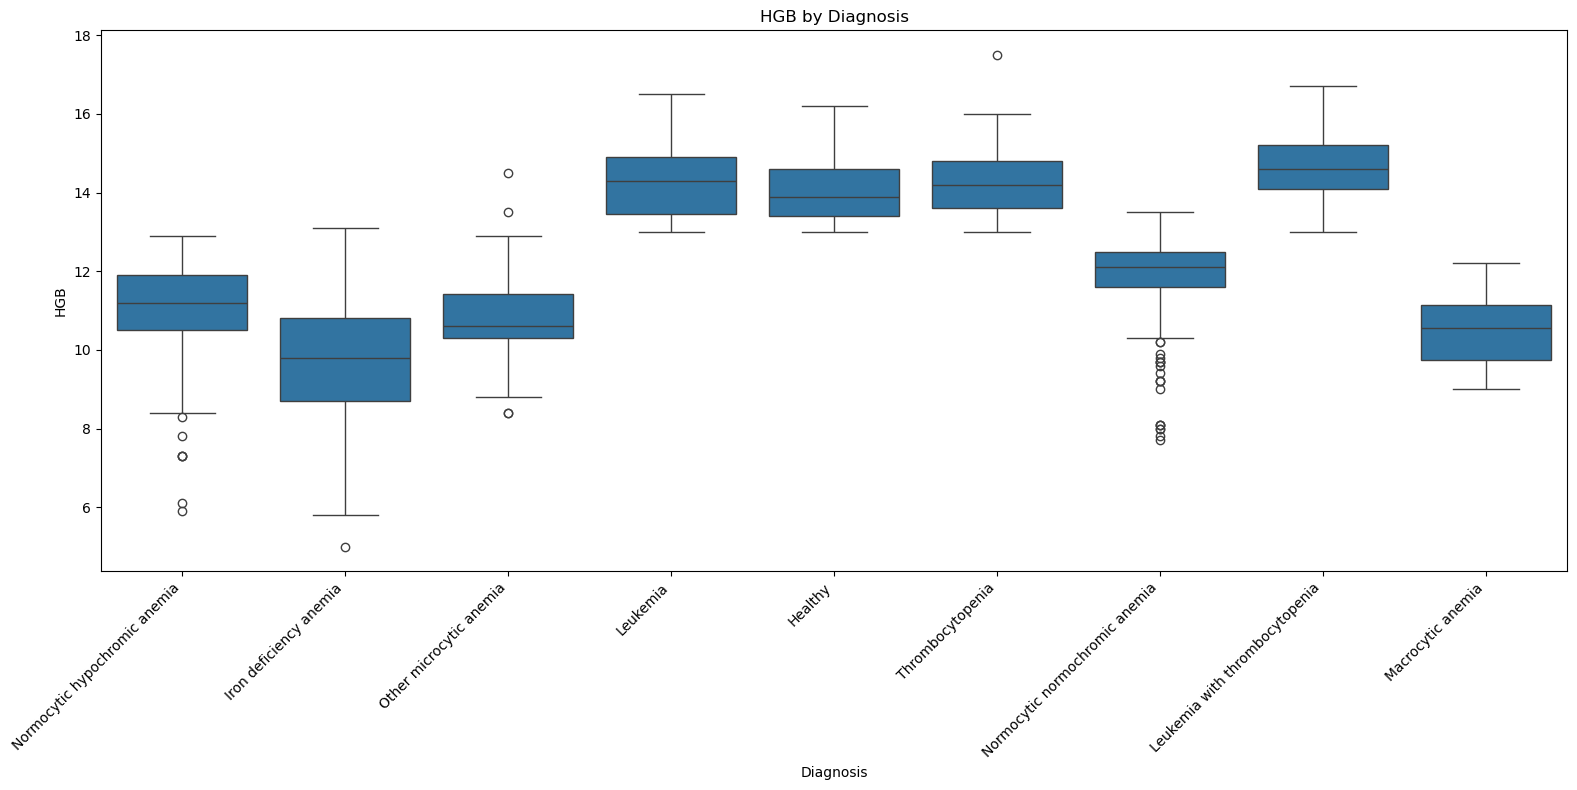

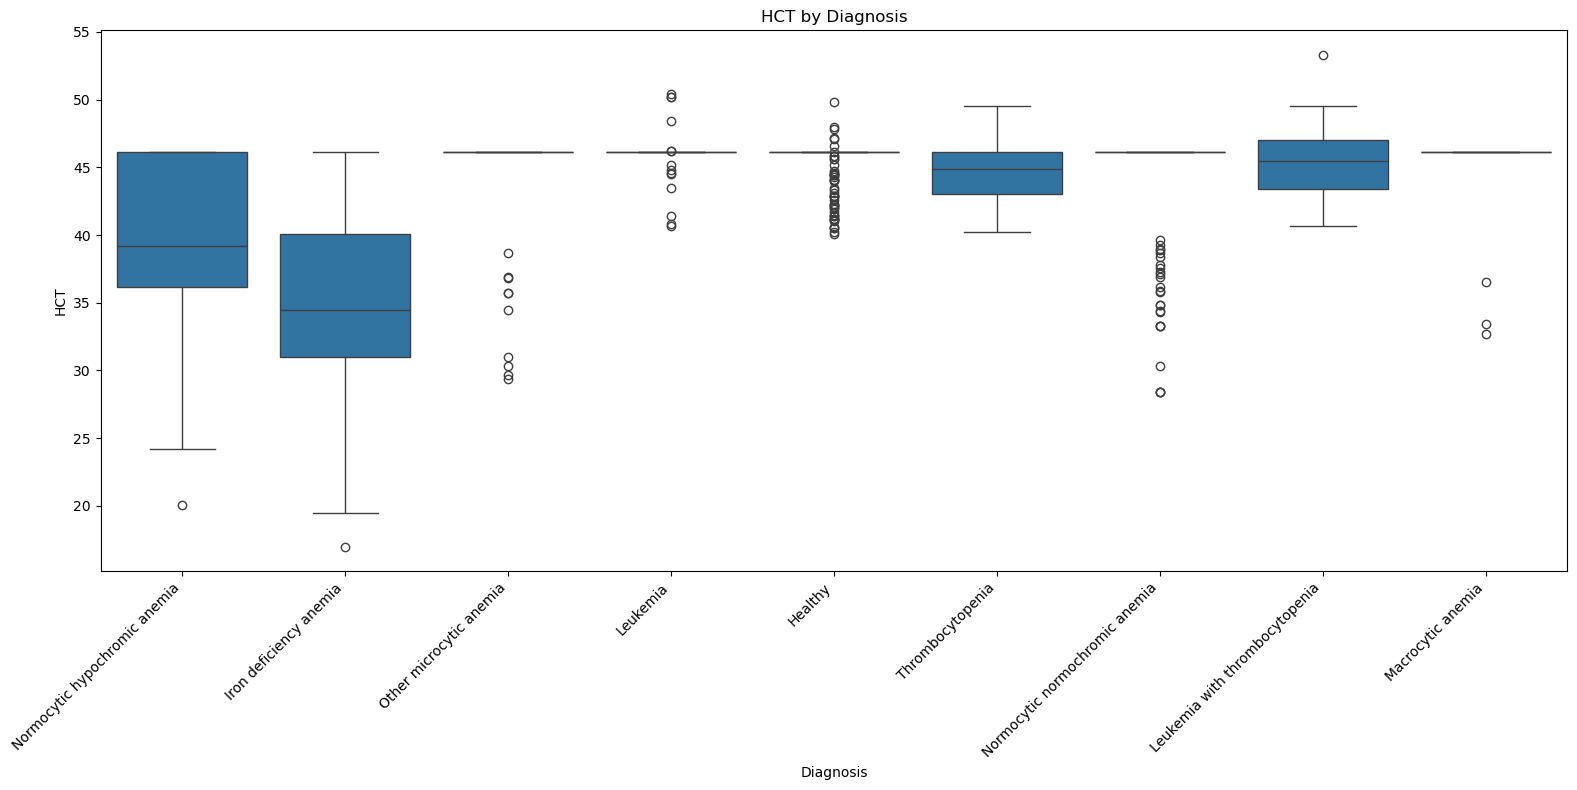

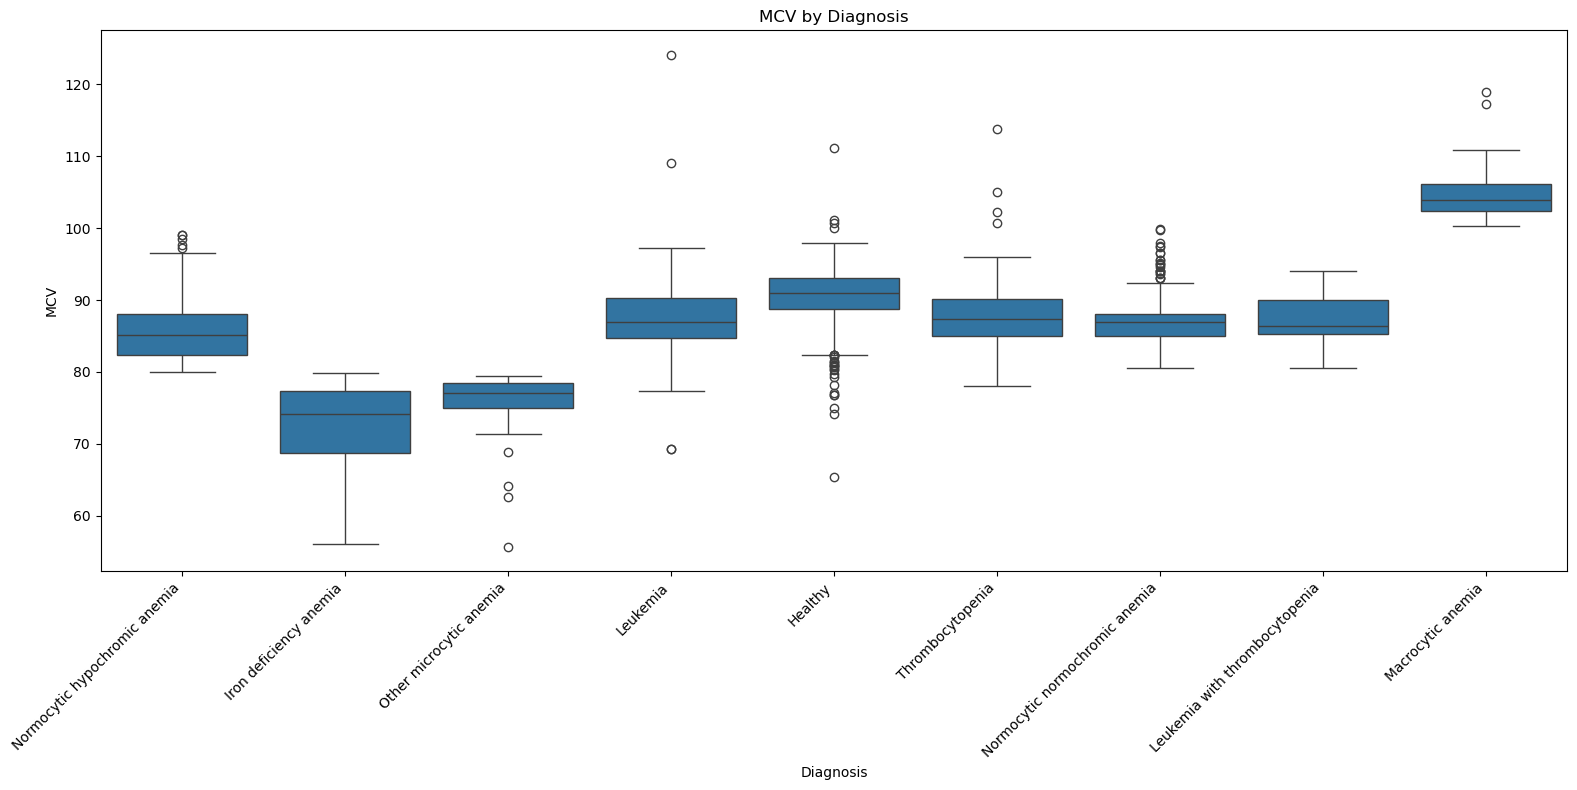

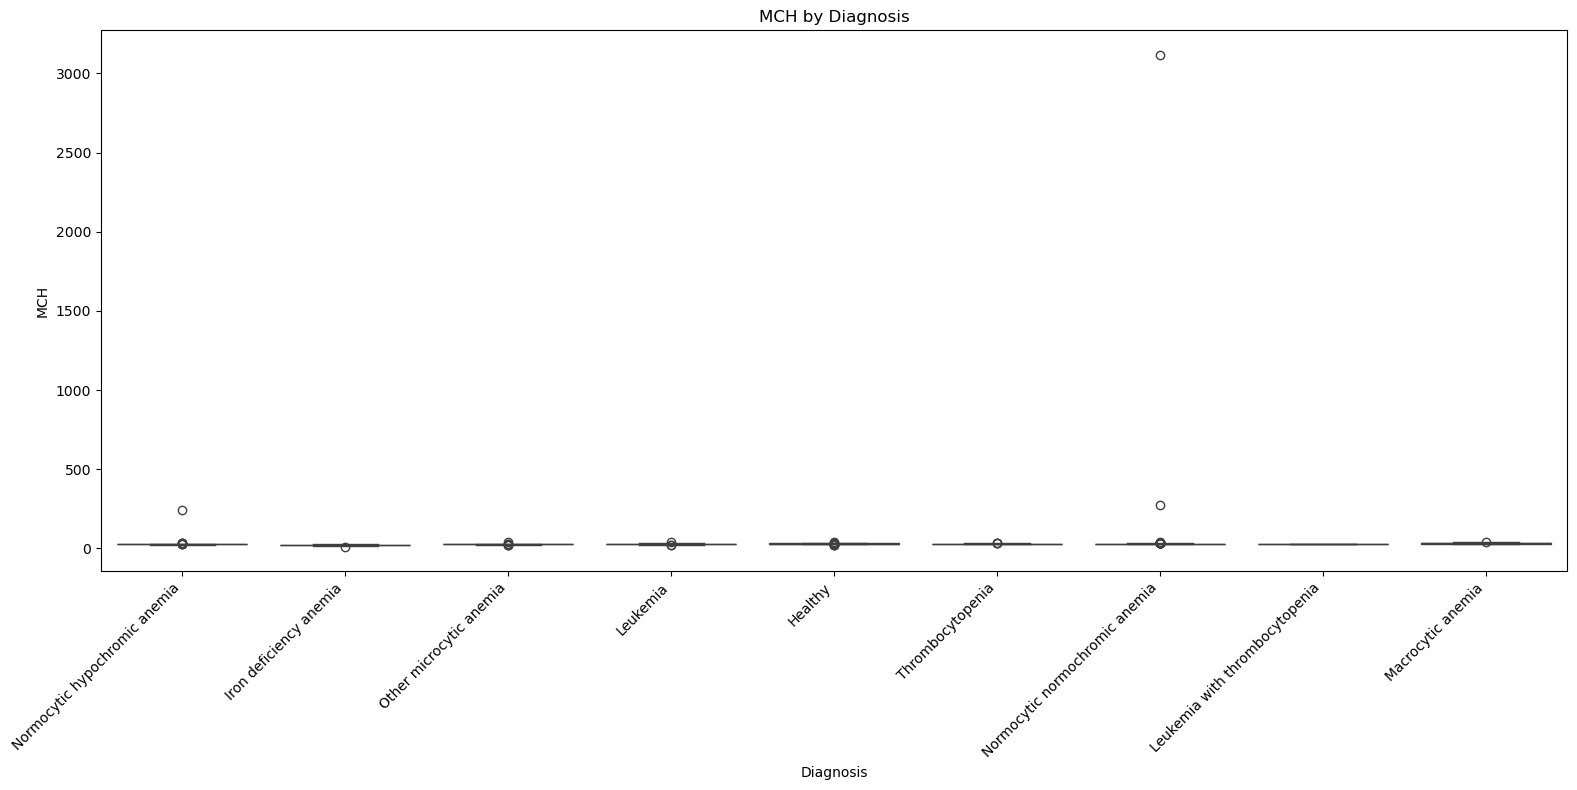

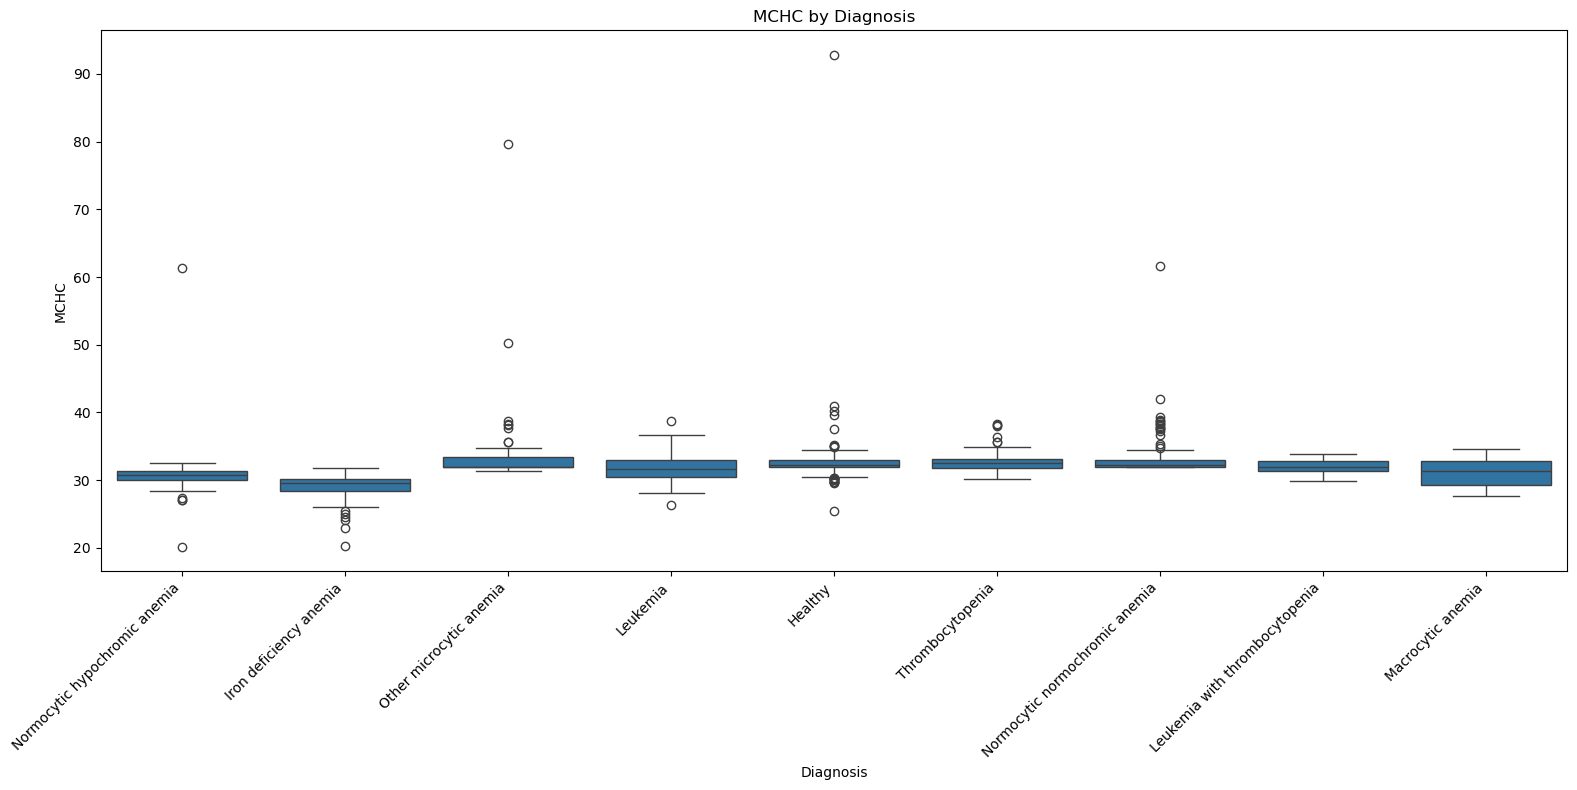

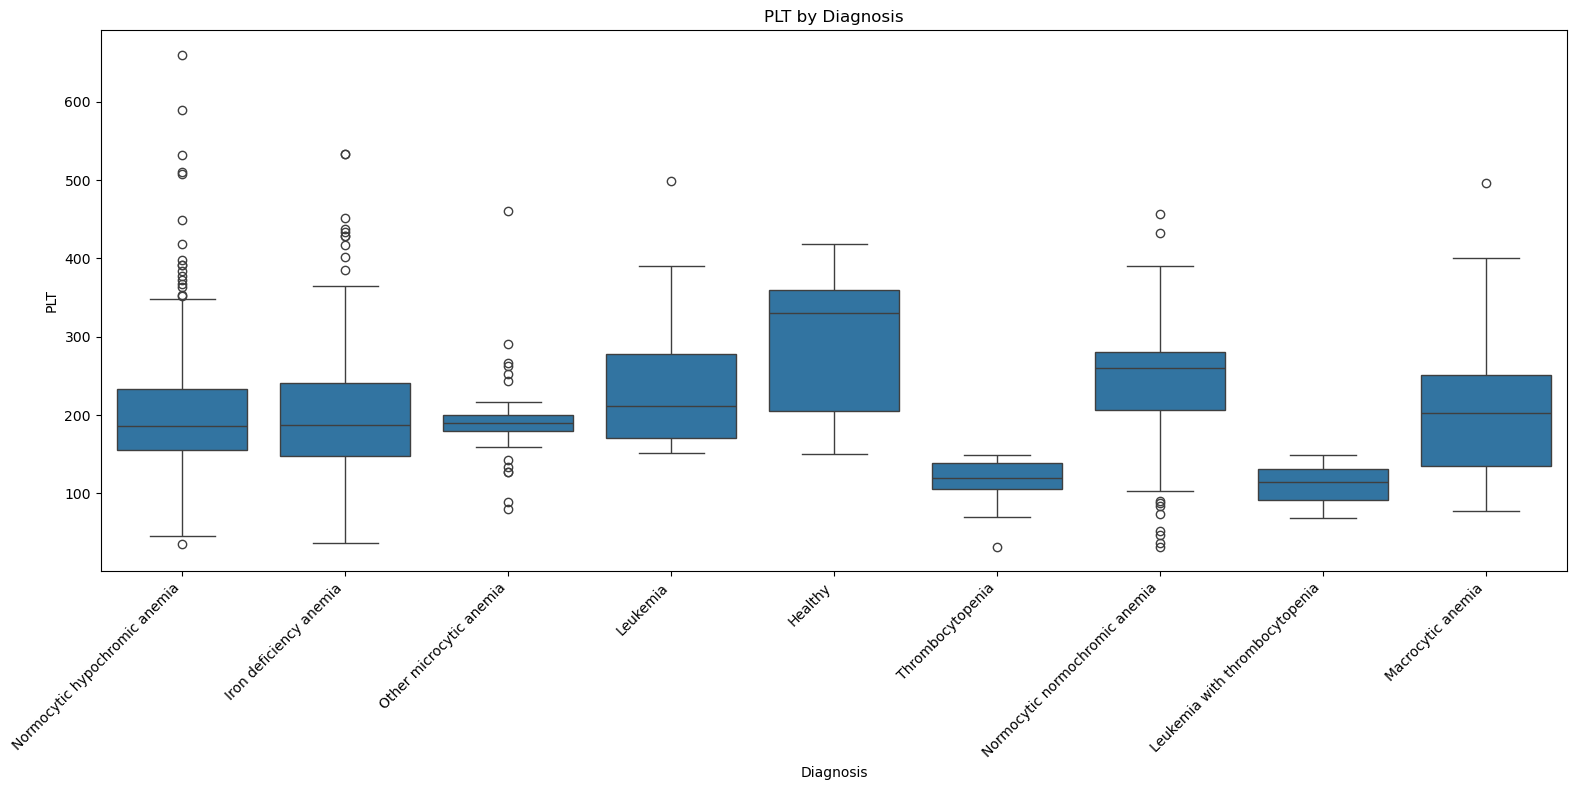

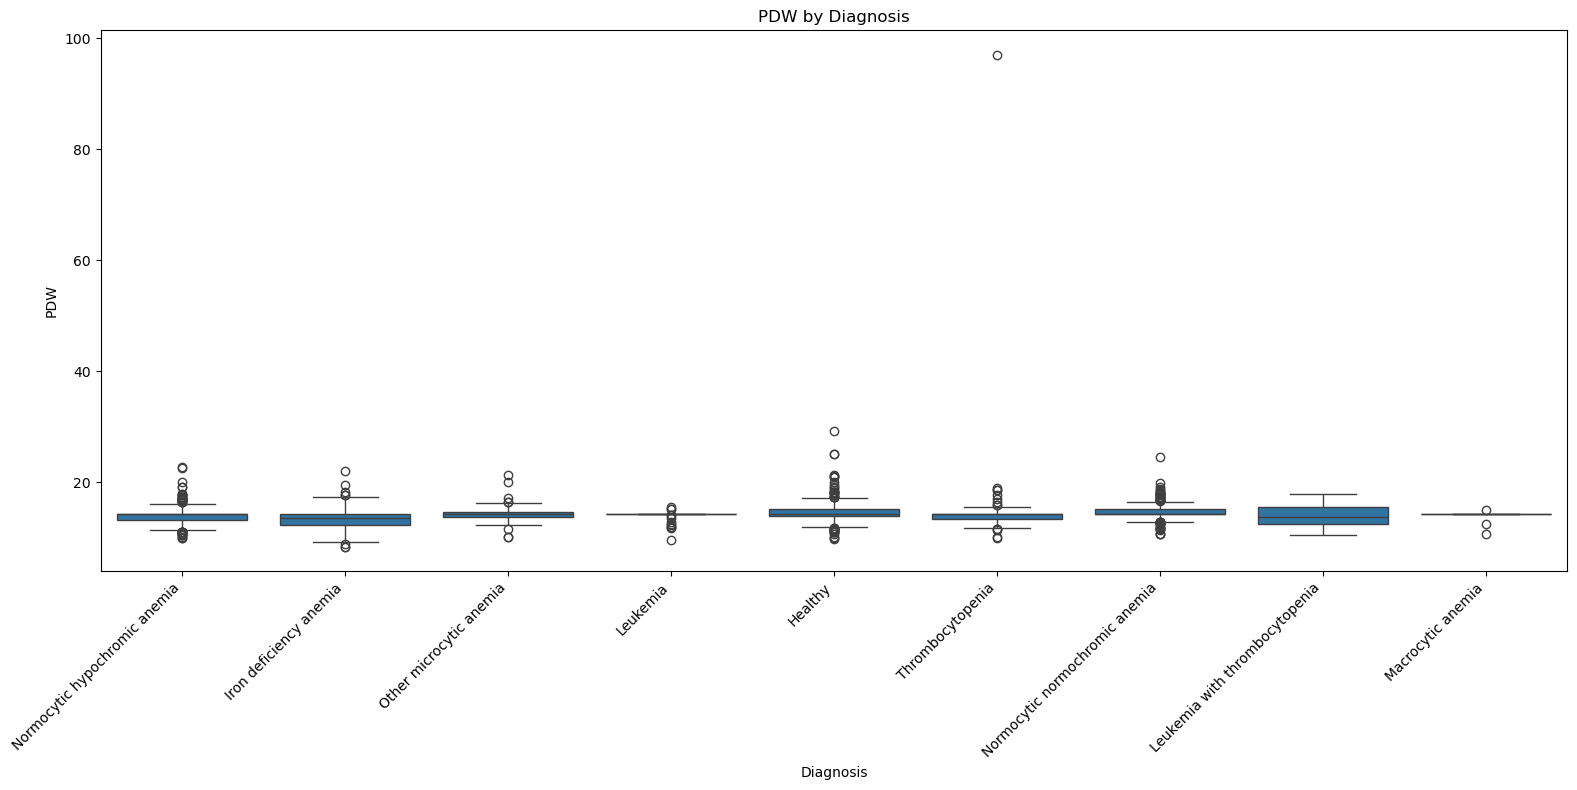

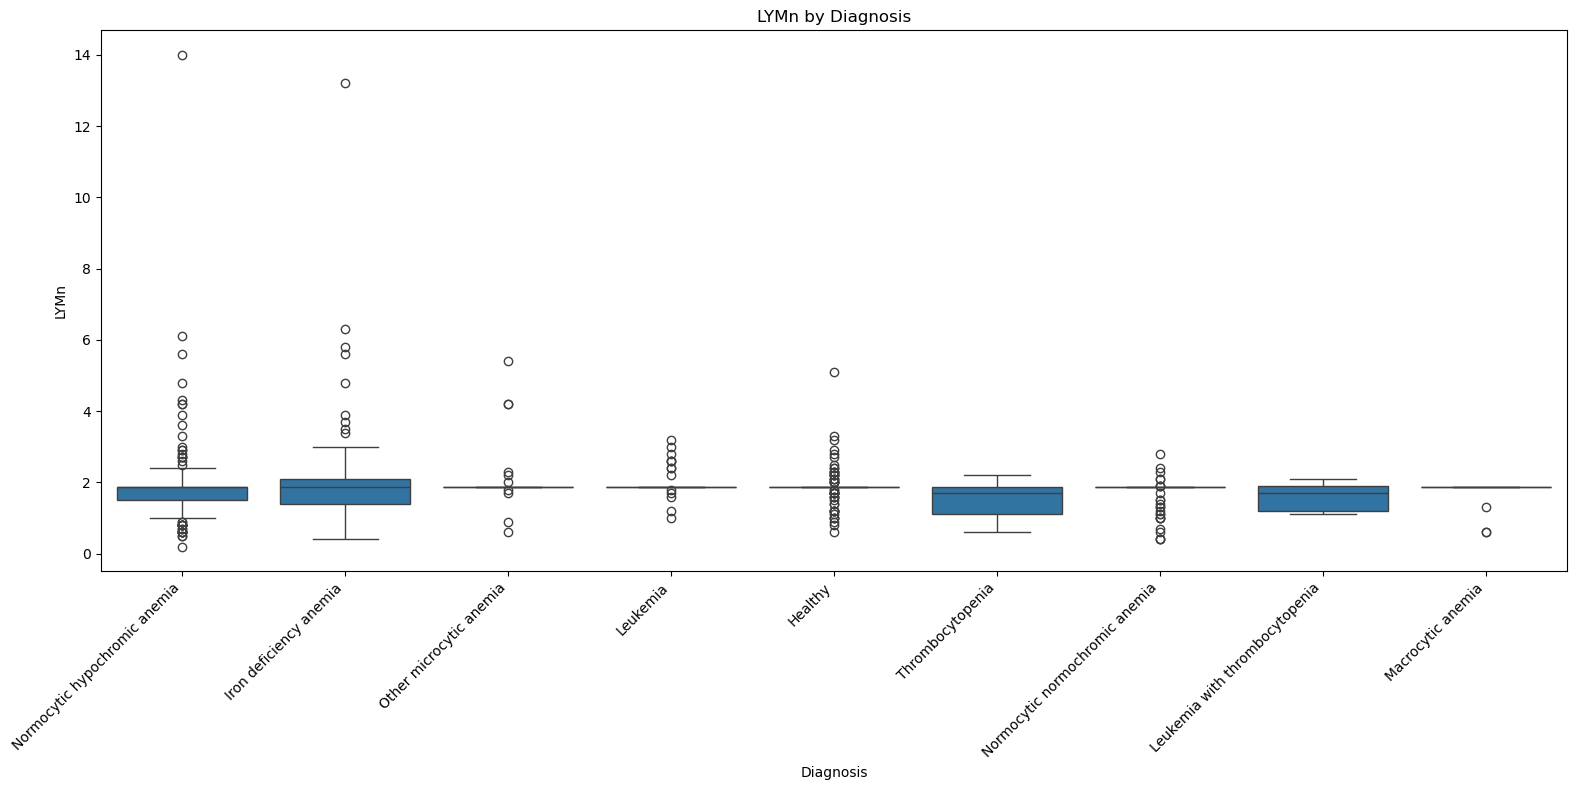

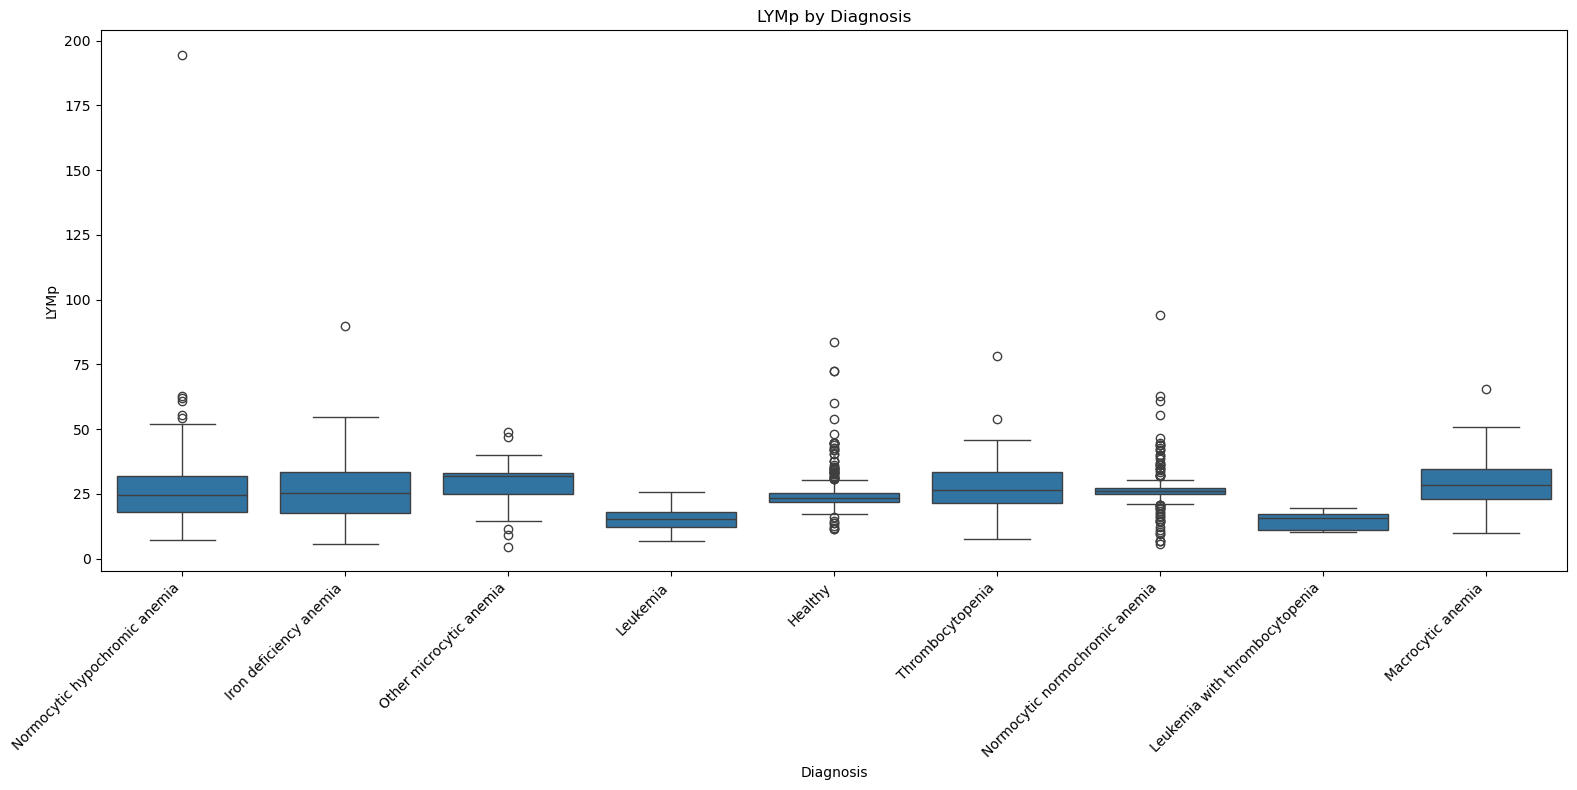

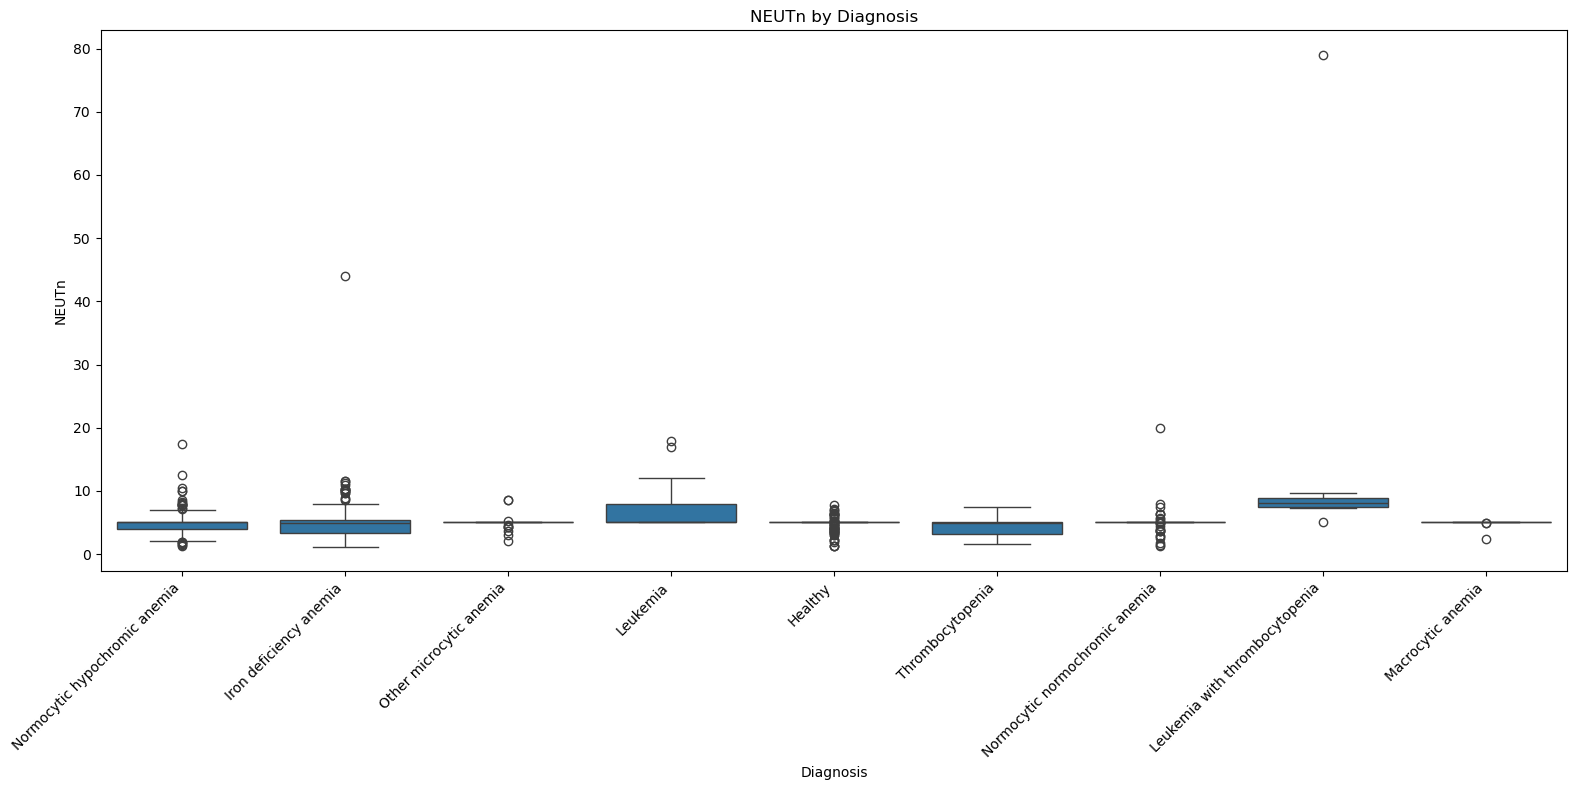

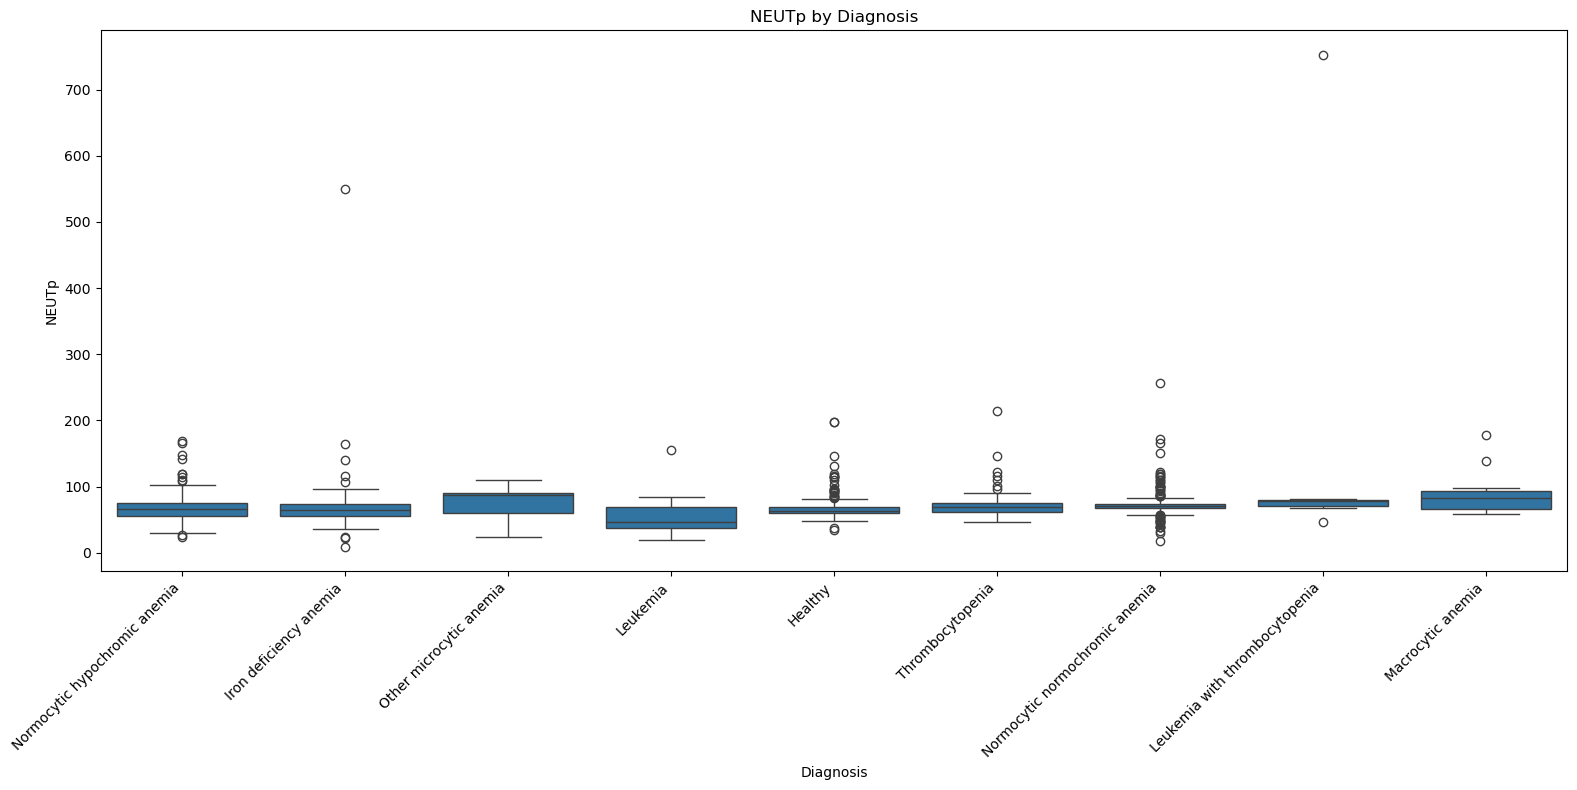

In [49]:
for col in numeric_features:
  plt.figure(figsize=(16, 8))

  sns.boxplot(data=df_clean, x='Diagnosis', y=col)

  plt.title(f"{col} by Diagnosis")
  plt.xlabel("Diagnosis")
  plt.ylabel(col)
  plt.xticks(rotation=45, ha="right")
  plt.tight_layout()
  plt.show()

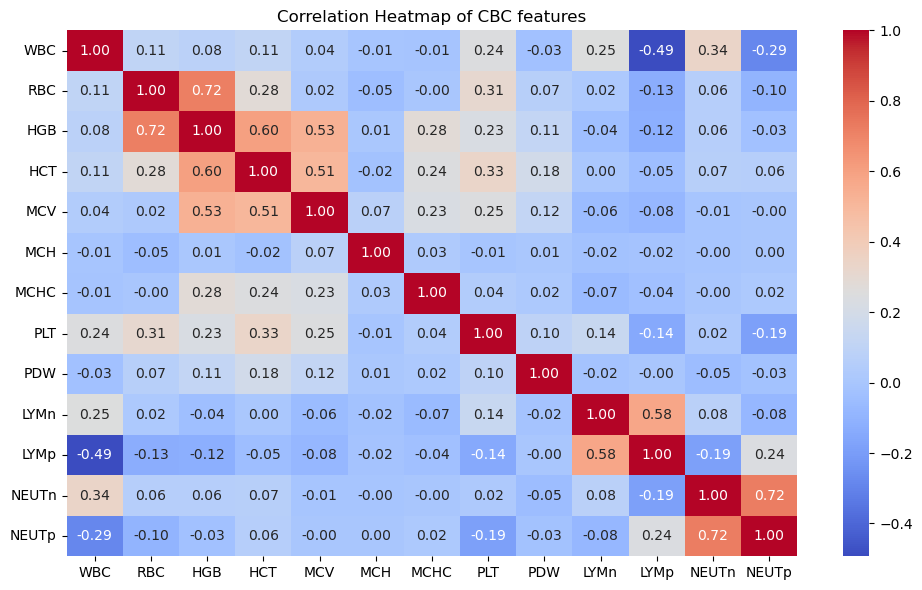

In [50]:
corr = df_clean[numeric_features].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr, cmap='coolwarm', fmt='.2f', annot=True)
plt.title('Correlation Heatmap of CBC features')
plt.tight_layout()
plt.show()

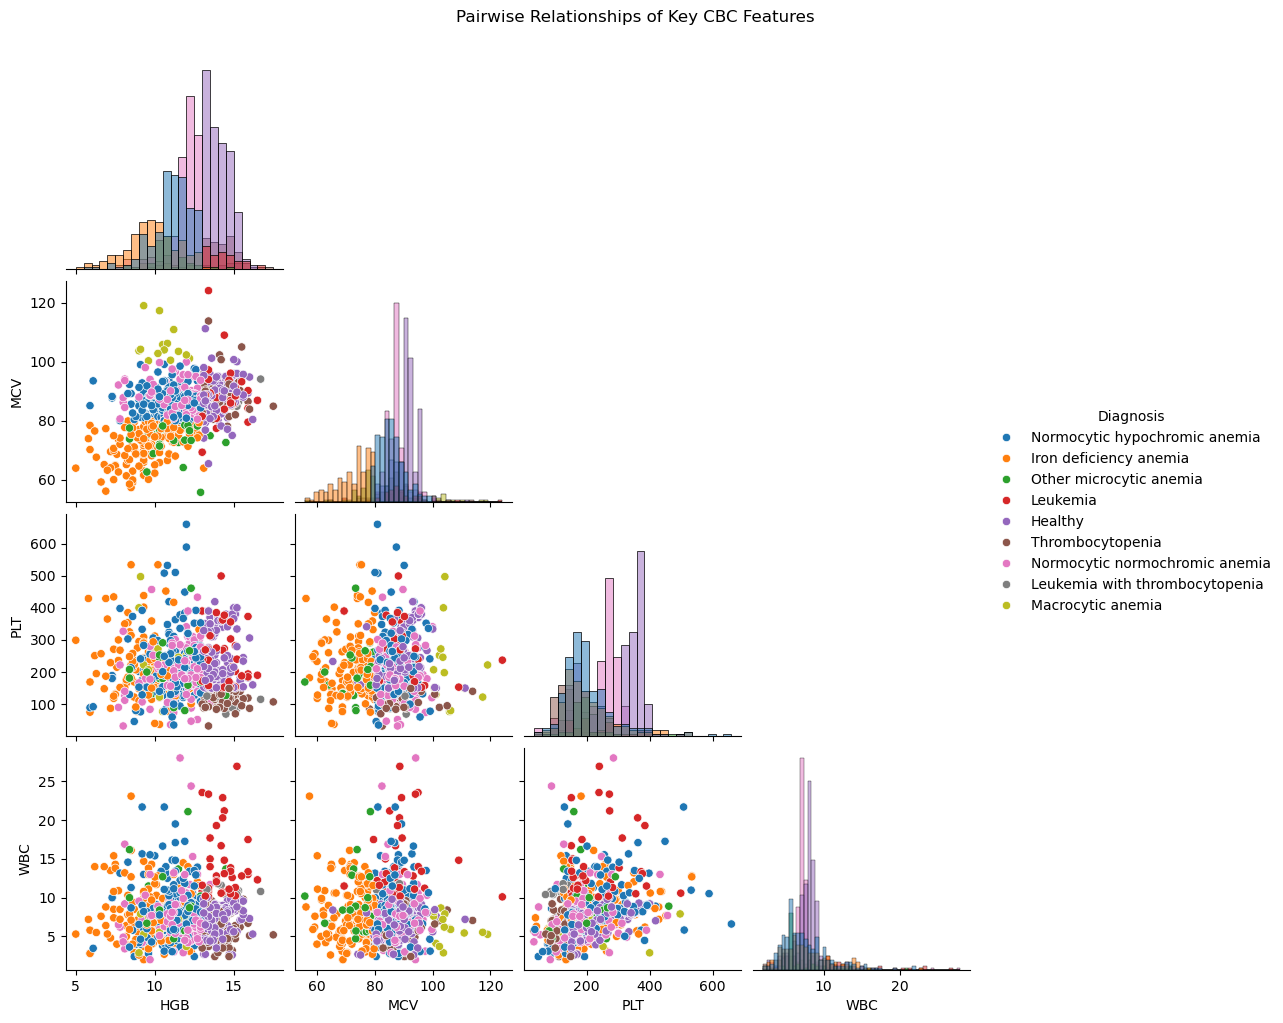

In [51]:
pairplot_features = [
    "HGB",
    "MCV",
    "PLT",
    "WBC"
]

sns.pairplot(
    df_clean,
    vars=pairplot_features,
    hue="Diagnosis",
    corner=True,
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationships of Key CBC Features",
    y=1.02
)

plt.show()

Feature Scaling


In [55]:
# Using StandardScaler
scaler = StandardScaler()
df_scaled = df_clean[['HGB', 'MCV', 'PLT', 'WBC']].copy()
df_scaled[['HGB', 'MCV', 'PLT', 'WBC']] = scaler.fit_transform(df_scaled)

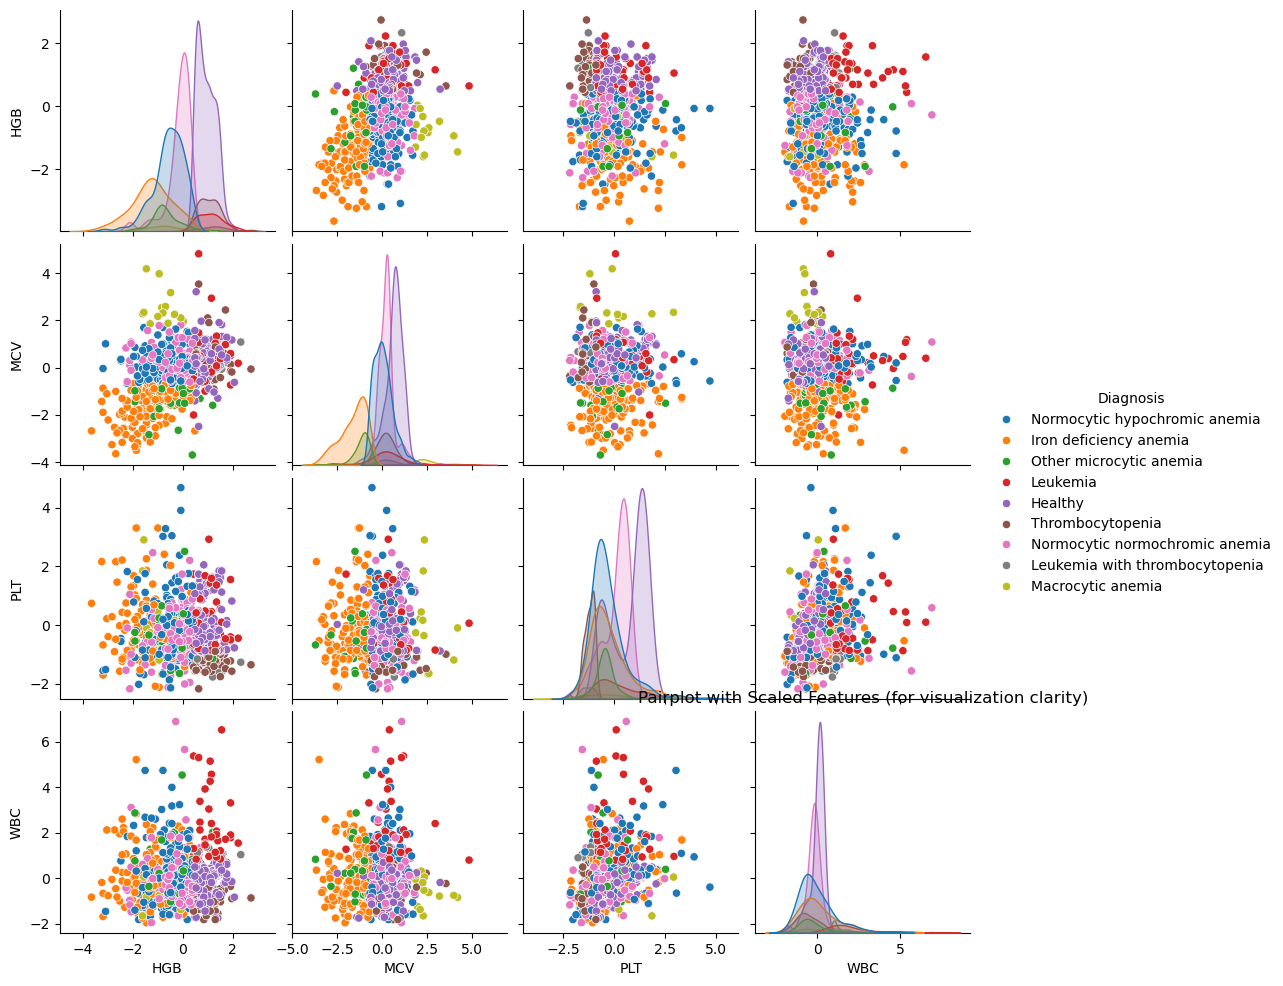

In [56]:
# Now make the pairplot with scaled data
sns.pairplot(df_scaled.assign(Diagnosis=df_clean['Diagnosis']), hue='Diagnosis')
plt.title('Pairplot with Scaled Features (for visualization clarity)')
plt.show()

### Saving Cleaned Dataset for Training the Model


In [57]:
# Verify df_clean is ready for modeling
print("Final dataset verification:")
print(f"Shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")
print(f"Data types:\n{df_clean.dtypes}")
print(f"\nNo NaNs: {df_clean.isnull().sum().sum() == 0}")
print(f"\nClass distribution:\n{df_clean['Diagnosis'].value_counts()}")

Final dataset verification:
Shape: (1194, 14)
Columns: ['WBC', 'LYMn', 'NEUTn', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'PLT', 'PDW', 'Diagnosis', 'LYMp', 'NEUTp']
Data types:
WBC          float64
LYMn         float64
NEUTn        float64
RBC          float64
HGB          float64
HCT          float64
MCV          float64
MCH          float64
MCHC         float64
PLT          float64
PDW          float64
Diagnosis     object
LYMp         float64
NEUTp        float64
dtype: object

No NaNs: True

Class distribution:
Diagnosis
Healthy                           323
Normocytic hypochromic anemia     257
Normocytic normochromic anemia    252
Iron deficiency anemia            175
Thrombocytopenia                   69
Other microcytic anemia            50
Leukemia                           43
Macrocytic anemia                  14
Leukemia with thrombocytopenia     11
Name: count, dtype: int64


In [58]:
# Save df_clean csv
df_clean.to_csv('cbc_cleaned_dataset_final.csv', index=False)
print(f"\n✅ Cleaned dataset saved: cbc_cleaned_final.csv")


✅ Cleaned dataset saved: cbc_cleaned_final.csv


In [59]:
df_test = pd.read_csv(r'cbc_cleaned_dataset_final.csv')
print(f"Loaded: {df_test.shape}, matches original: {df_test.shape == df_clean.shape}")

Loaded: (1194, 14), matches original: True
